# 🤖 1. Full Preprocessing Deep Learning Models - with Dropouts
**Deep learning models for retinal fundus image classification and refractive error regression**

The purpose of this notebook is to evaluate the small_cnn deep learning model for both binary myopia classification and spherical equivalent (SE) regression using fully preprocessed retinal fundus images. The dataset contains clinically acquired retinal fundus images linked to demographic and refractive information extracted from ophthalmological consultations. It consists of 2,126 fundus images.

In this stage of the project, the objectives are:
- To evaluate a lightweight CNN architecture for automated binary myopia classification.
- To evaluate a second CNN architecture adapted for refractive error regression using spherical equivalent (SE) values.

To analyze how fully preprocessed retinal fundus images behave in both classification and regression tasks.
These initial experiments will serve as a foundation for more advanced approaches (e.g., finding out which preprocessing step pushed models to do better), while highlighting the trade-offs between model complexity, training time, and classification accuracy.

The relevance of this work lies in its potential contribution to automated ophthalmology screening tools, aiming for faster and more accessible detection of myopia.

## ⚙️ 1. Setting up

Building a DataFrame with image paths and labels. Obtaining already split dataset into train, validation, and test sets (80/10/10) with stratification to keep class balance (avoids bias if one class bigger than the other).

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
# from sklearn.model_selection import train_test_split - not necessary, we'll be importing splits now
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os, random

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    get_experiment_paths,
    validate_main_structure,
    validate_experiment_paths,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, "full_preproc")
validate_experiment_paths(exp_paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

TABLE_PATH = exp_paths["table"]

SPLIT_DIR_CLASSF = exp_paths["split_classification"]
SPLIT_DIR_REGRSS = exp_paths["split_regression"]

MODELS_DIR_FULL = exp_paths["models_experiment"]
MODELS_DIR_FULL.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR_CLASSF)
print("Regression splits:", SPLIT_DIR_REGRSS)
print("Models output:", MODELS_DIR_FULL)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

df = pd.read_excel(TABLE_PATH)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Keep only images with valid path and existent SE targets
df = df[df["image_path"].notna()].copy()
df = df[df["target_SE"].notna()].copy()
df = df[df["class_label"].notna()].copy()

df["image_path"] = df["image_path"].astype(str)
df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("int32")

df = df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE", "class_label"]
).copy()

# Verify paths exist before training
missing_paths = df["image_path"].apply(lambda p: not Path(p).exists()).sum()
print("Missing image paths:", missing_paths)

assert missing_paths == 0, "Some image paths do not exist. Check the FullPreproc match table."

Missing image paths: 0


In [3]:
df["class_label"] = df["class_label"].astype("int32")
print("Total valid images (with SE):", len(df))
print("\nClassification label balance (0 = non-myopic, 1 = myopic)")
print(df["class_label"].value_counts())
print("\nTarget SE summary:")
print(df["target_SE"].describe())

Total valid images (with SE): 2126

Classification label balance (0 = non-myopic, 1 = myopic)
class_label
0    1645
1     481
Name: count, dtype: int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


#### 1.2. Train/Val/Test split

In [4]:
# Stratified 80/10/10 split across patients, in 00_CreatePatientLevelSplits_Classf_Regrss.ipynb
# Stratification is done using the classification label from the matches table to keep myopia/normal/mixed balance across splits

train_df_classf = pd.read_csv(SPLIT_DIR_CLASSF / "train.csv")
val_df_classf   = pd.read_csv(SPLIT_DIR_CLASSF / "val.csv")
test_df_classf  = pd.read_csv(SPLIT_DIR_CLASSF / "test.csv")

train_df_regrss = pd.read_csv(SPLIT_DIR_REGRSS / "train.csv")
val_df_regrss   = pd.read_csv(SPLIT_DIR_REGRSS / "val.csv")
test_df_regrss  = pd.read_csv(SPLIT_DIR_REGRSS / "test.csv")

print("Classification split sizes:")
print("Train:", len(train_df_classf))
print("Val:  ", len(val_df_classf))
print("Test: ", len(test_df_classf))

print("\nRegression split sizes:")
print("Train:", len(train_df_regrss))
print("Val:  ", len(val_df_regrss))
print("Test: ", len(test_df_regrss))


def check_no_overlap(train_df, val_df, test_df, column, name):
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


# Check patient-level separation
check_no_overlap(train_df_classf, val_df_classf, test_df_classf, "patient_id", "classification patient")
check_no_overlap(train_df_regrss, val_df_regrss, test_df_regrss, "patient_id", "regression patient")

# Check exact image separation too
check_no_overlap(train_df_classf, val_df_classf, test_df_classf, "image_path", "classification image")
check_no_overlap(train_df_regrss, val_df_regrss, test_df_regrss, "image_path", "regression image")

print("\nClassification label balance:")
print("Train:")
print(train_df_classf["class_label"].value_counts(normalize=True))
print("Val:")
print(val_df_classf["class_label"].value_counts(normalize=True))
print("Test:")
print(test_df_classf["class_label"].value_counts(normalize=True))

print("\nRegression target SE summary:")
print("Train:")
print(train_df_regrss["target_SE"].describe())
print("Val:")
print(val_df_regrss["target_SE"].describe())
print("Test:")
print(test_df_regrss["target_SE"].describe())

Classification split sizes:
Train: 1701
Val:   211
Test:  214

Regression split sizes:
Train: 1700
Val:   209
Test:  217
OK: no classification patient overlap across train/val/test.
OK: no regression patient overlap across train/val/test.
OK: no classification image overlap across train/val/test.
OK: no regression image overlap across train/val/test.

Classification label balance:
Train:
class_label
0    0.771899
1    0.228101
Name: proportion, dtype: float64
Val:
class_label
0    0.781991
1    0.218009
Name: proportion, dtype: float64
Test:
class_label
0    0.780374
1    0.219626
Name: proportion, dtype: float64

Regression target SE summary:
Train:
count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64
Val:
count    209.000000
mean       0.069976
std        1.860834
min      -14.000000
25%       -0.375000
50%        0.000000
75%        0.750

- Final dataset used in this notebook contains 2,126 valid retinal fundus images with available spherical equivalent and binary myopia labels
- The **class distribution is clearly imbalanced**: 1,645 images correspond to the normal/non-myopic class and 481 images correspond to the myopic class. Therefore, approximately 77% of the images belong to the normal class and only 23% to the myopic class.
- Checking the splits we see they were performed correctly at patient level and image level, with no overlap between train, validation and test sets. The class proportions remain similar across the three splits, which confirms that the stratification process worked properly.

This imbalance is important when interpreting the classification results, since a model that simply predicted all images as normal would already obtain a relatively high accuracy. For this reason, **AUC, Precision-Recall curves and the confusion matrix are more informative than accuracy alone.**

For the regression task, the SE distribution is highly concentrated around 0 D, with a median of 0 D and a wide range of extreme values. This indicates that many samples are close to emmetropia or low refractive error, while only a limited number of images correspond to high refractive errors. This **distribution can make regression difficult, since predicting values close to the population mean may already produce a relatively low MAE.**

#### 1.3. Building TF datasets

Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

def decode_img(path, y):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) # decodes jpg into RGB tensor
    img = tf.image.convert_image_dtype(img, tf.float32)  # converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    return img, y #gives pic+corresponding label/target

# Lightweight augmentations
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])


In [6]:
def make_classification_ds(csv_path, training=False): #creating the TensorFlow dataset for binary classf
    df_split = pd.read_csv(csv_path)
    paths = df_split["image_path"].astype(str).values
    labels = df_split["class_label"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

def make_regression_ds(csv_path, training=False): #creating the TensorFlow dataset for SE regrss
    df_split = pd.read_csv(csv_path)
    
    paths = df_split["image_path"].astype(str).values
    targets = df_split["target_SE"].astype("float32").values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True) 
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

In [7]:
train_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "train.csv", training=True) #shuffle + augmentations
val_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "test.csv", training=False) #decode + batching (no augs)

train_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "train.csv", training=True) #shuffle + augmentations
val_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "test.csv", training=False) #decode + batching (no augs)

## 🧩 2. The models

#### 🟢 2.1. First model: small_cnn_classification
Now, we define our first small CNN for binary classification, that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

This was our small_cnn in the previous Telecommunications thesis, let's see how it'll do with our newly acquired clinical dataset.

In [8]:
def build_small_cnn_classf(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="sigmoid")(x) #binary exit (1 is the probability of myopia)
    return keras.Model(inputs, outputs)

model_classf = build_small_cnn_classf()

model_classf.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with lr=1e-3
              loss="binary_crossentropy", #adecuate for binary classification with sigmoid
              metrics=[keras.metrics.AUC(name="auc"), "accuracy"]) #AUC and accuracy metrics  

In [9]:
model_classf.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️2.1.2. Callbacks for classification
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [10]:
# Building callbacks for later use
cb_classf = [ 
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=train_df_classf["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class

class_weight = {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras
print("Class weights:", class_weight)

Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}


The computed class weights were 0.65 for the normal class and 2.19 for the myopic class. This means that **errors on myopic images were penalized more strongly during training**, compensating for the lower number of myopic samples.

This correction is useful because the dataset is imbalanced. However, it **can also shift the model towards predicting more positive/myopic cases**, increasing the number of false positives. This **effect is later visible in the confusion matrix**, where several normal images are incorrectly classified as myopic.

#### 2.1.3 Training classification model

In [11]:
history_classf = model_classf.fit(train_ds_classf, validation_data=val_ds_classf, epochs=10, callbacks=cb_classf, class_weight=class_weight) 
# Proper training using our tf.data pipelines (train_ds, val_ds):
# Applies class_weight to penalize errors on the minority class more strongly
# Runs for up to 10 epochs, but EarlyStopping may stop earlier if val_auc does not improve

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.5564 - auc: 0.4486 - loss: 0.6991 - val_accuracy: 0.7820 - val_auc: 0.5177 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6636 - auc: 0.5663 - loss: 0.7012 - val_accuracy: 0.5735 - val_auc: 0.5588 - val_loss: 0.6883 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.3967 - auc: 0.5353 - loss: 0.6965 - val_accuracy: 0.7820 - val_auc: 0.5462 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.4116 - auc: 0.5521 - loss: 0.6868 - val_accuracy: 0.5640 - val_auc: 0.5391 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6109 - auc: 0.5627 - loss: 0.6958 - val_accuracy: 0.5687 - val_auc: 0.5451 - val_loss: 0.6822 - learning_rate: 3.0000e-04
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6825 - auc: 0.55

In [12]:
test_metrics_classf = history_classf.model.evaluate(test_ds_classf, return_dict=True)
test_metrics_classf

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 513ms/step - accuracy: 0.6065 - auc: 0.5996 - loss: 0.6883


{'accuracy': 0.644859790802002,
 'auc': 0.6157472133636475,
 'loss': 0.6870130896568298}

Note: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Let's see how our model did:

Taking a first look, it seems as the model did not do a very god job, having got an **accuracy of 64.49% and an AUC of 61.57%**. These results where better in the other thesis.

Let's see how the performance changes applying a regression model.

#### 🟠 2.2 Second model: small_cnn_regression
The same lightweight CNN backbone is adapted for refractive error regression by replacing the sigmoid classification head with a linear output neuron predicting continuous spherical equivalent (SE) values.

In [13]:
def build_small_cnn_regrss(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="linear")(x) # Regression output: one continuous value, e.g. -2.75 diopters
    return keras.Model(inputs, outputs)

model_regrss = build_small_cnn_regrss()

model_regrss.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with low error 
        loss="mse", #adecuate for regression calculations (Mean Squared Error)
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.MeanSquaredError(name="mse")]) #Mean Absolute Error and accuracy metrics

Let's see how our model did:

In [14]:
model_regrss.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️2.2.2. Callbacks for regression

In [15]:
cb_regrss = [ 
    keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if MAE not lower after 5 epochs, stop training and go back to best weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if MAE stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

#### 2.2.3 Training regression model

In [16]:
history_regrss = model_regrss.fit(train_ds_regrss, validation_data=val_ds_regrss, epochs=10, callbacks=cb_regrss) 
# Proper training using our tf.data regression pipelines
# The model learns to predict a continuous SE value in diopters
# Runs for up to 10 epochs, but EarlyStopping may stop it earlier if validation MAE does not improve.

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 4.2198 - mae: 1.1799 - mse: 4.2198 - val_loss: 3.4608 - val_mae: 1.0154 - val_mse: 3.4608 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - loss: 4.9485 - mae: 1.2484 - mse: 4.9485 - val_loss: 3.4392 - val_mae: 1.0173 - val_mse: 3.4392 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - loss: 4.6041 - mae: 1.2410 - mse: 4.6041 - val_loss: 3.4392 - val_mae: 1.0016 - val_mse: 3.4392 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 4.8154 - mae: 1.2736 - mse: 4.8154 - val_loss: 3.4407 - val_mae: 1.0042 - val_mse: 3.4407 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - loss: 4.1919 - mae: 1.1937 - mse: 4.1919 - val_loss: 3.4413 - val_mae: 1.0104 - val_mse: 3.4413 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 4.6502 - mae: 1.2425 - mse: 4.6502 - val_loss: 3.4176 - val_mae: 1.0109 - val

In [17]:
test_metrics_regrss = history_regrss.model.evaluate(test_ds_regrss, return_dict=True)
test_metrics_regrss

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - loss: 4.0140 - mae: 1.1903 - mse: 4.0140


{'loss': 3.252384901046753,
 'mae': 1.0328919887542725,
 'mse': 3.252384901046753}

Although the **MAE may seem acceptable at first glance (1.033), it must be interpreted carefully** because many target values are close to 0 D. In this context, predicting values close to the population mean can already lead to a moderate MAE without actually learning meaningful image-based refractive information.

In [18]:
# Save trained models
CLASSF_MODEL_PATH = MODELS_DIR_FULL / "small_cnn_classification_with_dropout_fullpreproc.keras"
REGRSS_MODEL_PATH = MODELS_DIR_FULL / "small_cnn_regression_with_dropout_fullpreproc.keras"

model_classf.save(CLASSF_MODEL_PATH)
model_regrss.save(REGRSS_MODEL_PATH)

print("Classification model saved at:", CLASSF_MODEL_PATH)
print("Regression model saved at:", REGRSS_MODEL_PATH)

Classification model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc\small_cnn_classification_with_dropout_fullpreproc.keras
Regression model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc\small_cnn_regression_with_dropout_fullpreproc.keras


## 📊 3. Results of classification and regression models

#### 📈 3.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for one or multiple Keras models, making it easy to compare performance across epochs.

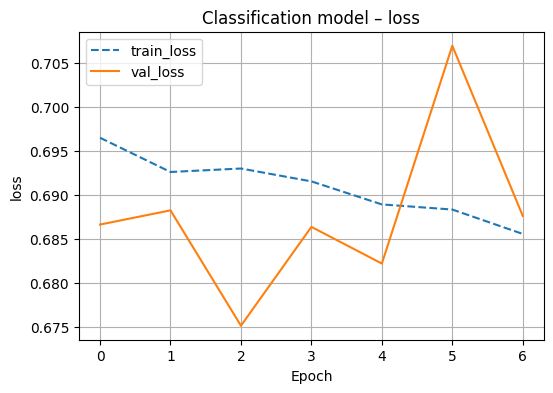

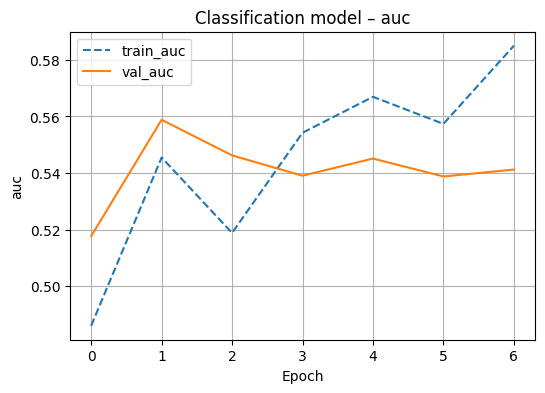

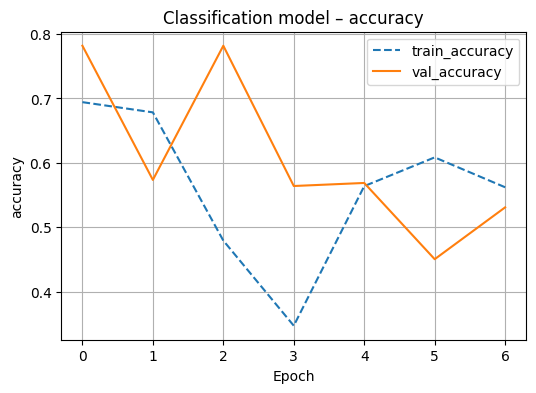

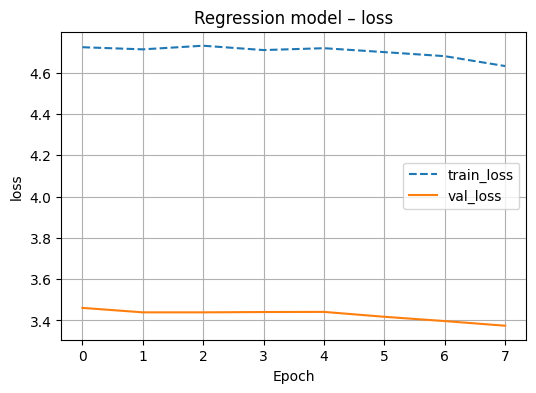

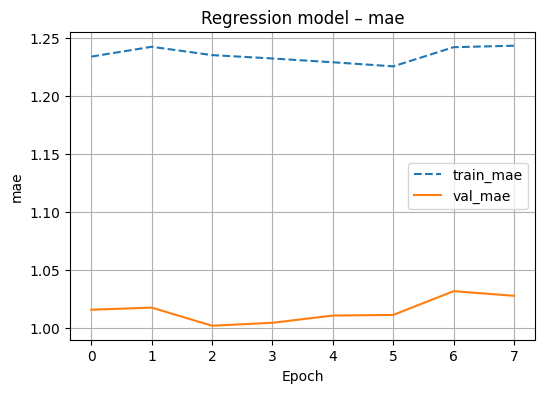

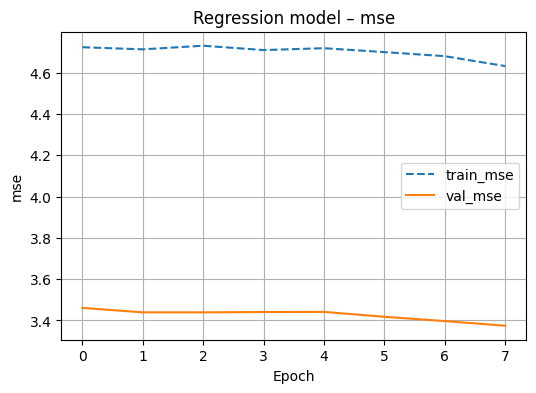

In [19]:
def plot_histories(history, metrics, title):
    #histories: list of keras History objects returned after training
    #metrics: e.g. "auc" | "accuracy" | "loss" -  metrics to visualize during training
    #title: list of names e.g. ["Classification", "Regression"]

    for metric in metrics:
        plt.figure(figsize=(6,4))
        
        if metric in history.history:
            plt.plot(history.history[metric], linestyle="--", label=f"train_{metric}")
        
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{title} – {metric}")
        plt.legend()
        plt.grid(True)
        plt.show()

#classf
plot_histories(
    history_classf,
    metrics=["loss", "auc", "accuracy"],
    title="Classification model"
)

#regrss
plot_histories(
    history_regrss,
    metrics=["loss", "mae", "mse"],
    title="Regression model"
)


CLASSIFICATION:

The classification model stopped after 7 epochs due to **early stopping**. The best validation AUC was reached very early, around epoch 2, with a value close to 0.56. After that point, the validation AUC did not improve substantially, and the learning rate was progressively reduced.

The training AUC increases slightly over the epochs, but the validation AUC remains almost flat and close to random performance. This suggests that the **model is not learning robust discriminative features** from the fully preprocessed images in this configuration.

The validation accuracy reaches values around 0.78 in some epochs, but this value should not be interpreted as strong performance. Since approximately 78% of the validation set belongs to the normal class, this **accuracy is close to what would be obtained by predicting all samples as normal**. Therefore, the AUC and the confusion matrix provide a more realistic view of model performance.

-> Overall, the training curves do not show clear overfitting. Instead, they suggest **limited learning capacity** for this specific task and preprocessing configuration.

REGRESSION:

During training, the validation MAE remains around 1.0 D and does not improve substantially after the first epochs. The training MAE remains slightly higher than the validation MAE, which **does not indicate overfitting**. This difference may be partly explained by the use of data augmentation in training and by the fact that the validation set has a slightly lower spread in spherical equivalent values than the training set.

The model appears to converge, but it converges towards a very simple solution: **predicting values close to the mean of the target distribution.**

#### 🧪 3.2 Collect predictions & eval on test set
Evaluating trained models on the test set, collecting predictions, plotting ROC and Precision–Recall curves, showing the confusion matrix if there is one, and returning metrics such as AUC, AP, accuracy, and a classification report.

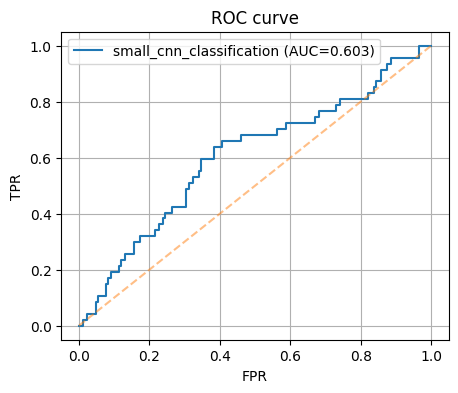

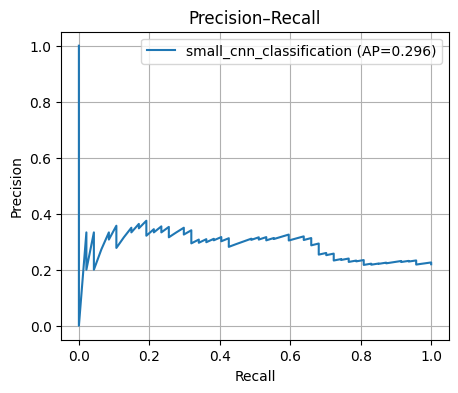

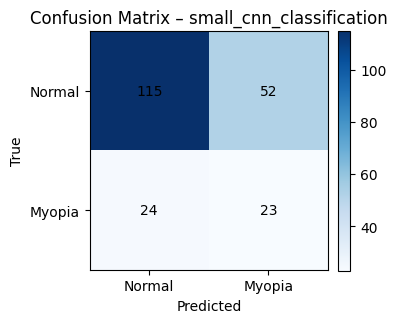

              precision    recall  f1-score   support

      Normal       0.83      0.69      0.75       167
      Myopia       0.31      0.49      0.38        47

    accuracy                           0.64       214
   macro avg       0.57      0.59      0.56       214
weighted avg       0.71      0.64      0.67       214



In [20]:
#CLASSIFICATION:

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

def collect_classification_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    
    return y_true, y_score

def evaluate_classification_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"]
    )

    if show_plots:
        # ROC curve: sensitivity to false positives (True Positive Rate vs False Positive Rate)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1], [0,1], "--", alpha=0.5)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("ROC curve")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR: precission vs recall
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix: TP/TN/FP/FN
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal", "Myopia"])
        plt.yticks([0,1], ["Normal", "Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc), #Quality of segreggation
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()), #% Correctness
        "confusion_matrix": cm,
        "report": report
    }

# Example usage:
res_classf = evaluate_classification_on_test(
    "small_cnn_classification",
    model_classf,
    test_ds_classf
)

print(res_classf["report"])

The confusion matrix shows 115 true normal predictions, 52 normal images incorrectly classified as myopic, 24 myopic images incorrectly classified as normal, and 23 correctly classified myopic images.

This means that the model makes **76 errors out of 214 test images, corresponding to an error rate of approximately 35.5%**.

The model identifies normal cases better than myopic cases, with a **recall of 0.69 for the normal class and 0.49 for the myopic class**. However, the precision for the myopic class is low, around 0.31, meaning that many images predicted as myopic are actually normal.

This behaviour suggests that the **model is sensitive to the class weighting strategy, which encourages the detection of myopic cases but also increases false positives**. From a clinical perspective, the model would not yet be reliable enough, since it misses around half of the myopic cases and also incorrectly flags many normal cases as myopic.

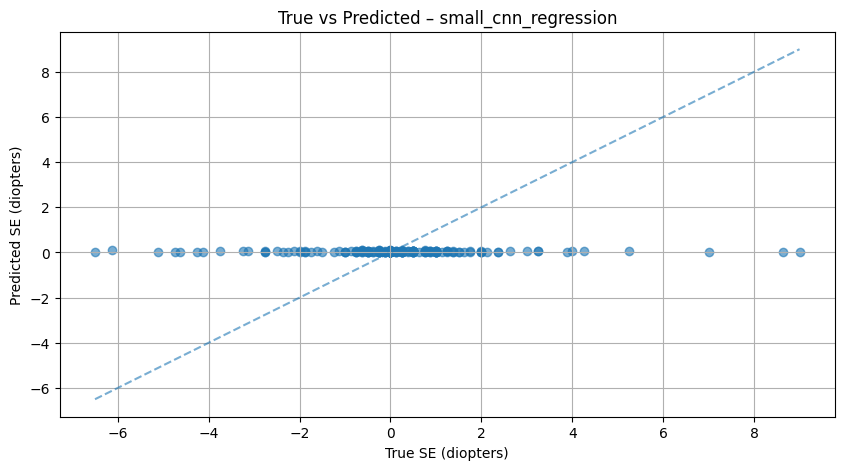

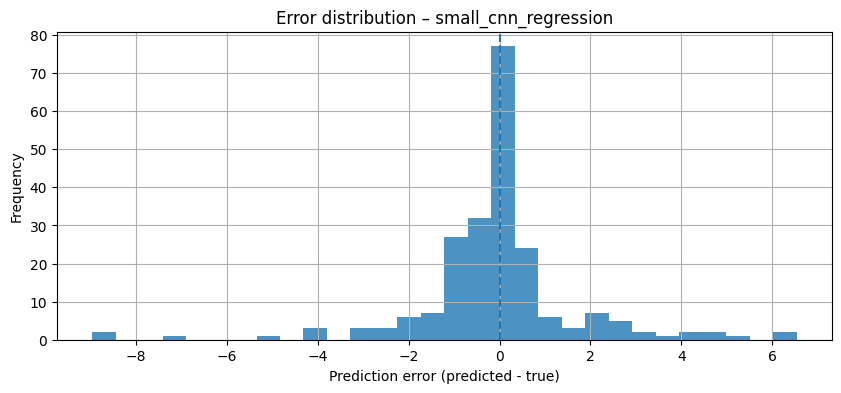

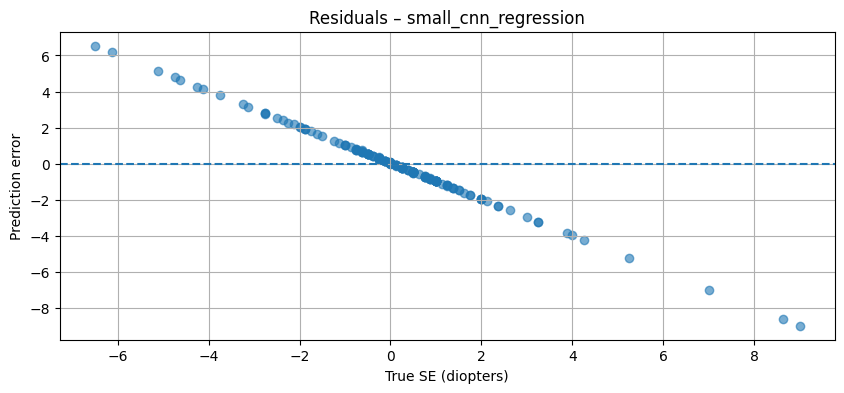

{'name': 'small_cnn_regression',
 'MAE': 1.0328919541236647,
 'MSE': 3.2523852237589876,
 'RMSE': 1.8034370584411832,
 'R2': -0.001603343885972608}

In [21]:
#REGRESSION:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def collect_regression_preds(model, ds): #dataset as ds
    y_true, y_pred = [], [] # True SE values and predicted SE values
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(p.tolist())
    
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    
    return y_true, y_pred

def evaluate_regression_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_regression_preds(model, test_ds)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    errors = y_pred - y_true

    if show_plots:
        # true vs predicted SE values
        plt.figure(figsize=(10,5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()
        
        # Distribution of prediction errors
        plt.figure(figsize=(10,4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        # # Residual plot: relationship between prediction error and true SE
        plt.figure(figsize=(10,4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

#Example usage:
res_regrss = evaluate_regression_on_test(
    "small_cnn_regression",
    model_regrss,
    test_ds_regrss
)

res_regrss

The true-vs-predicted plot shows that almost all predictions are concentrated around 0 D, regardless of the true SE value. This confirms that the **model has collapsed towards predicting the central tendency of the dataset rather than learning** a real mapping between retinal appearance and refractive error.

This behaviour is also confirmed numerically. In the training set, the predicted values have a mean of approximately 0.046 D and a standard deviation of only 0.018 D (bottom of notebook), while the true target values have a standard deviation of approximately 2.17 D. The predicted range is extremely narrow, from approximately 0.014 D to 0.166 D, while the true values range from -20.375 D to 9 D.

This indicates that the model is not capturing the variability of the SE. It is essentially predicting almost the same value for all images.

The residual plot shows a very clear linear pattern: negative refractive errors tend to have positive prediction errors, while positive refractive errors tend to have negative prediction errors. This is the **expected pattern when a model predicts a value close to zero for almost every sample.**

The **error distribution is centred around zero, but this does not mean the regression is good**. It simply reflects that the model predicts the mean of a distribution that is itself centred near zero. The residual structure confirms that the model systematically underestimates positive values and fails to capture negative values, especially more myopic cases.

#### ⚖️ 3.3 Direct comparison: classification and regression experiments
This code evaluates both models on the same test set to compare their performance directly.

In [22]:
summary_results = pd.DataFrame([
    {
        "model": "small_cnn_classification",
        "task": "classification",
        "test_auc": res_classf["AUC"],
        "test_ap": res_classf["AP"],
        "test_accuracy@0.5": res_classf["accuracy@0.5"],
        "test_mae": np.nan,
        "test_mse": np.nan,
        "test_rmse": np.nan,
        "test_r2": np.nan
    },
    {
        "model": "small_cnn_regression",
        "task": "regression",
        "test_auc": np.nan,
        "test_ap": np.nan,
        "test_accuracy@0.5": np.nan,
        "test_mae": res_regrss["MAE"],
        "test_mse": res_regrss["MSE"],
        "test_rmse": res_regrss["RMSE"],
        "test_r2": res_regrss["R2"]
    }
])

summary_results

,model,task,test_auc,test_ap,test_accuracy@0.5,test_mae,test_mse,test_rmse,test_r2
0,small_cnn_classification,classification,0.603007,0.29576,0.64486,NaN,NaN,NaN,NaN
1,small_cnn_regression,regression,NaN,NaN,NaN,1.032892,3.252385,1.803437,-0.001603


#### 🗂️ 3.4 Quick “experiment card” (dict of results)
This function summarizes a training experiment, extracting config details, best validation metrics, and test results, and organizes them into a dictionary that can be displayed as a comparison table.

In [23]:
def summarize_classification_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "classification",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_acc": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "test_auc": test_metrics_dict["AUC"],
        "test_ap": test_metrics_dict["AP"],
        "test_acc@0.5": test_metrics_dict["accuracy@0.5"]
    }
    return summary

def summarize_regression_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "regression",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_mae": float(np.min(history.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(history.history.get("val_mse", [np.nan]))),
        "test_mae": test_metrics_dict["MAE"],
        "test_mse": test_metrics_dict["MSE"],
        "test_rmse": test_metrics_dict["RMSE"],
        "test_r2": test_metrics_dict["R2"]
    }

    return summary

In [24]:
class CFG:
    INPUT_TABLE = TABLE_PATH
    IMAGE_SIZE = 224                  # final square size (e.g., 224 tamaño og, 256 tamaño habitual ImageNet, 299)
    APPLY_CLAHE = True                # cCntrast Limited Adaptive Histogram Equalization
    CLAHE_MODE = "luminance"          # choosing CLAHE channel from "luminance" | "green" | "blue" | "none"
    NORMALIZATION = "0-1"             # "0-1" | "zscore" | "imagenet"
    VERBOSE = True                    # gives messages while preprocessing for visual progress

# Example usage:
card_classf = summarize_classification_experiment(
    "small_cnn_classification",
    CFG,
    history_classf,
    res_classf
)

card_regrss = summarize_regression_experiment(
    "small_cnn_regression",
    CFG,
    history_regrss,
    res_regrss
)

pd.DataFrame([card_classf, card_regrss])

,name,task,image_size,clahe,normalization,best_val_auc,best_val_acc,test_auc,test_ap,test_acc@0.5,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2
0,small_cnn_classification,classification,224,luminance,0-1,0.558827,0.781991,0.603007,0.29576,0.64486,NaN,NaN,NaN,NaN,NaN,NaN
1,small_cnn_regression,regression,224,luminance,0-1,NaN,NaN,NaN,NaN,NaN,1.001623,3.374377,1.032892,3.252385,1.803437,-0.001603


The classification model shows limited discriminative capacity, with a test AUC around 0.60 and an Average Precision of 0.296. The regression model, on the other hand, does not learn a meaningful continuous prediction of spherical equivalent, as shown by its R² value close to zero and its baseline-like behaviour.

Therefore, in this notebook, **classification appears to be more promising than regression, but neither result is strong enough** to be considered a final model.

## 📌 5. Conlusions

The first relevant conclusion is that the **dataset is clearly imbalanced**, with a much larger number of normal images than myopic images. This makes accuracy difficult to interpret and highlights the importance of AUC, Average Precision and confusion matrices.

For **classification**, the model obtains moderate but limited performance:
- The test AUC is around 0.60, the Average Precision is 0.296 and the accuracy is 64.5%.
- Although the model performs slightly above random classification, it remains below the majority-class accuracy baseline.
- The confusion matrix shows that the model detects only about half of the myopic cases and produces a considerable number of false positives.
Therefore, the model is not robust enough for clinical use in this configuration.

For **regression**, the results are weaker:
- The model obtains a MAE close to 1.03 D and an R² approximately equal to zero.
- The prediction plots show that the model predicts almost the same value for all samples, very close to 0 D. This means that the model has essentially learned the mean of the population rather than extracting useful information from the retinal images.
- The comparison with the baseline confirms that the regression model does not improve meaningfully over a simple mean predictor.

Overall, the results suggest that **fully preprocessed images alone are not sufficient to obtain strong performance with this architecture**. The classification task seems more feasible than direct SE regression, but the current model remains limited. The regression task appears especially difficult with this image-only small CNN approach, probably due to the target distribution being highly concentrated around 0 D and the visual signal being too weak or too subtle for this architecture.

These results justify evaluating alternative preprocessing strategies, architectures and regularization choices in the following notebooks. In particular, it will be important to compare whether selective preprocessing scenarios improve classification performance and whether removing Dropout or modifying the regression strategy changes the behaviour observed here.

End :)

In [25]:
y_train_true, y_train_pred = collect_regression_preds(model_regrss, train_ds_regrss)

train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_mse = mean_squared_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_true, y_train_pred)

print("Train MAE :", train_mae)
print("Train RMSE:", train_rmse)
print("Train R²  :", train_r2)

Train MAE : 1.2257095677454901
Train RMSE: 2.1711556747527805
Train R²  : 0.0014444233763929448


In [26]:
print("Train mean prediction:", np.mean(y_train_pred))
print("Train std prediction :", np.std(y_train_pred))

print("Train mean target    :", np.mean(y_train_true))
print("Train std target     :", np.std(y_train_true))

Train mean prediction: 0.04629436394583215
Train std prediction : 0.0179305695074921
Train mean target    : 0.006029411764705882
Train std target     : 2.1727254094839736


In [27]:
print("Pred min:", y_train_pred.min())
print("Pred max:", y_train_pred.max())

print("True min:", y_train_true.min())
print("True max:", y_train_true.max())

Pred min: 0.013947517611086369
Pred max: 0.16587410867214203
True min: -20.375
True max: 7.75


-> con esta arquitectura y esta información visual, el modelo no es capaz de extraer suficiente información para estimar dioptrías continuas mejor que predecir la media de la población.

In [28]:
train_df_regrss["target_SE"].describe()

count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64

In [29]:
y_mean = np.mean(y_train_true)

y_test_true, y_test_pred = collect_regression_preds(model_regrss, test_ds_regrss)

baseline_pred = np.full_like(y_test_true, y_mean)

print("Baseline MAE:",
      mean_absolute_error(y_test_true, baseline_pred))

print("Baseline RMSE:",
      np.sqrt(mean_squared_error(y_test_true, baseline_pred)))

print("Baseline R2:",
      r2_score(y_test_true, baseline_pred))

Baseline MAE: 1.0274146110056925
Baseline RMSE: 1.80433475591696
Baseline R2: -0.0026007289304239567


✓ No hay overfitting

✓ No parece un problema de train/test split

✓ No parece un problema de early stopping

✓ No parece un problema de ReduceLROnPlateau

✓ El modelo converge correctamente


✗ El modelo aprende esencialmente la media de la población

✗ No supera al baseline

✗ R² ≈ 0 tanto en train como en test


The baseline model, which predicts the mean spherical equivalent from the training set for all test samples, obtained a MAE of 1.027 D, an RMSE of 1.804 D and an R² of -0.0026.

The CNN regression model obtained very similar results: MAE of 1.033 D, RMSE of 1.803 D and R² of -0.0016. The differences are negligible and do not represent a meaningful improvement over the baseline.

Therefore, **the regression model does not provide clinically useful predictive value in this configuration. Its behaviour is almost equivalent to predicting the mean refractive error for every image.**